# Try to finally get this thing over with

In [1]:
import numpy as np
import cdv_utils
import matplotlib.pyplot as plt
import importlib
import glob
import re
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA


plt.rcParams['text.usetex'] = True
plt.rcParams['pgf.texsystem'] = "pdflatex"
plt.rcParams['text.latex.preamble'] = (
    r'\usepackage{amsmath,amsfonts,amssymb,cmbright,standalone}')
importlib.reload(cdv_utils)

<module 'cdv_utils' from '/home/schoelleh96/Nextcloud/AGPfahl/AGMeeting/20241119_PaperClub/code/code_deposit/cdv_utils.py'>

In [68]:
import pickle
from cdv_utils import (
    load_d, plot_lifetime_distributions_lines, diffusion_maps_matrix,
    compute_clusters_from_TO, classify_new_trajectory, calculate_escape_times,
    expected_escape_times_from_TO, add_scaled_top_axis, make_L3d, spy_col,
    solve_escape_from_Q, affinity_entry_sum, plot_loglog_slope_analysis,
    fit_hmm)
fixed = np.array([
    [0.7285286,   0.15657308, -0.36810966, -0.32854071, -0.08004622, 0.34314342],
    [0.94484848, 0.10714876, -0.00858286, -0.71094887, -0.17206714, 0.03996197]
])

/tmp/ipykernel_11138/920139421.py:31: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_11138/920139421.py:33: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


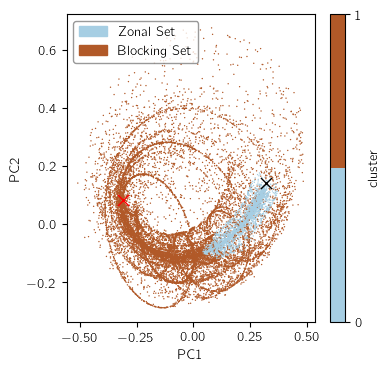

In [44]:

epsilon = 0.005
subsample_step = 10
n_eig = 12
n_clusters = 2
n_init = 10
eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
random_state = 0
det_traj = load_d(
    "./cdv_model/data/dataOro20_sigma0p00000000.bin", 6, 200000)[::subsample_step, :]

# DMM, A = diffusion_maps_matrix(det_traj, epsilon)

L = make_L3d(det_traj, epsilon)

# --- compute clusters from TO ---
det_cluster_res = compute_clusters_from_TO(L.T,
                                           n_eig=n_eig,
                                           n_clusters=n_clusters,
                                           n_init=n_init,
                                           eig_indices=eig_indices,
                                           random_state=random_state)
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(det_traj)
fixed_pcs = pca.transform(fixed)
labels = det_cluster_res["labels"].copy()
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(labels)))
sc = plt.scatter(PC_scores[:-1, 0], PC_scores[:-1, 1],
                 c=labels, s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

handles = [
    mpatches.Patch(color=cmap(0), label=f'Zonal Set'),
    mpatches.Patch(color=cmap(1), label=f'Blocking Set')
]
plt.legend(
    handles=handles,
    loc='upper left',           # position inside the plot
    frameon=True,
    framealpha=0.8,             # slightly transparent background
    facecolor='white',
    edgecolor='gray'
)
plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
cbar.set_label('cluster')
cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))

In [47]:
# check above
blocking_idx = 0  # <- change this
blocking_mask = labels == blocking_idx
dt_traj = 1e-2
dt_dict = {}
dt_dict_MonteCarlo = {}

Text(0, 0.5, 'X6')

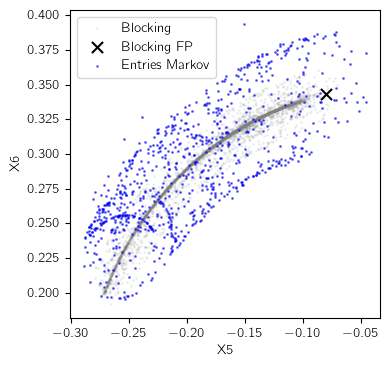

In [33]:
entries = np.where(
    (labels[:-1] != blocking_idx) & (labels[1:] == blocking_idx))[0]+1
blocking_points = det_traj[np.where(labels == blocking_idx)[0]]
plt.figure(figsize=(4, 4))
sc = plt.scatter(blocking_points[:, 4], blocking_points[:, 5], color="gray", s=1, label='Blocking',
                 rasterized=True, alpha=0.1)
plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
            alpha=1, marker="x", label="Blocking FP")
# plt.scatter(fixed[1, 4], fixed[1, 5], c='red', s=64,
#             alpha=1, marker="x", label="Zonal FP")

plt.scatter(det_traj[entries, 4], det_traj[entries, 5], c='blue', s=1, label='Entries Markov',
            rasterized=True, alpha=0.5)

plt.legend()
plt.xlabel("X5")
plt.ylabel("X6")

In [34]:
blocking_points.shape

(5573, 6)

## Investigate dt dependence

38.608783783783785
[sparse-direct] used splu (n=19047, nnz=18899, density=5.209e-05).
38.608783783783785
entries: 148
blocking states: (19047,)
Processing sigma=0.0
Processing sigma=0.005
Processing sigma=0.01
Processing sigma=0.015
Processing sigma=0.02
Processing sigma=0.025
Processing sigma=0.03
Processing sigma=0.035
Processing sigma=0.04
Processing sigma=0.045
Processing sigma=0.05
38.89795918367347
[sparse-direct] used splu (n=11436, nnz=11289, density=8.632e-05).
38.89795918367347
entries: 147
blocking states: (11436,)
Processing epsilon = 0.000000
[sparse-direct] used splu (n=11436, nnz=11289, density=8.632e-05).
Processing epsilon = 0.000025
[sparse-direct] used splu (n=11436, nnz=5528921, density=0.04228).
Processing epsilon = 0.000100
[iterative] GMRES converged with ILU preconditioner (n=11436, nnz=13692929, density=0.1047).
Processing epsilon = 0.000225
[iterative] GMRES converged with ILU preconditioner (n=11436, nnz=23041947, density=0.1762).
Processing epsilon = 0.00040

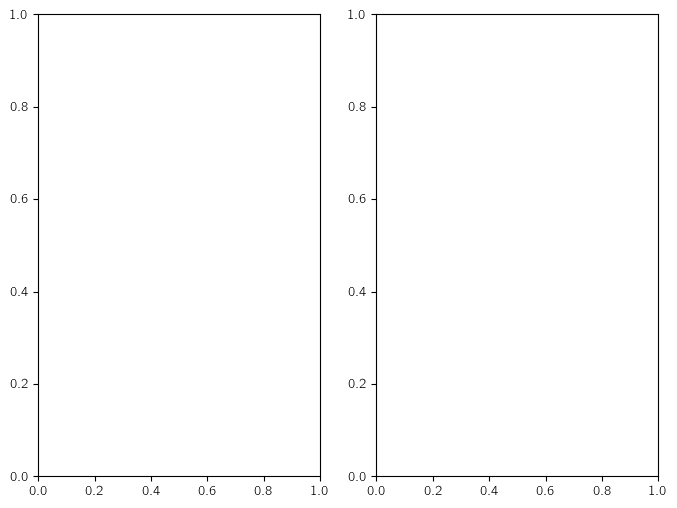

In [ ]:
# dt_dict = {}
# dt_dict_MonteCarlo = {}
for subsample_step_TO in [20, 50, 75, 100, 150, 200]:
    max_points = 7e4
    t_fin = int(subsample_step_TO * max_points)
    dt_eff_TO = dt_traj * subsample_step_TO
    det_traj_TO = load_d(
        "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
    labels_TO = classify_new_trajectory(
        det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
    )
    print(np.asarray(calculate_escape_times(
        labels_TO, dt=dt_eff_TO)[blocking_idx]).mean())
    entries = np.where(
        (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
    indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
        entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])

    L = make_L3d(det_traj_TO, 0)
    Q = L[labels_TO[:-1] == blocking_idx][:,
                                          labels_TO[:-1] == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q) * dt_eff_TO
    print(t_escape[indices_in_reduced].mean())
    print("entries:", entries.shape[0])
    print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)

    t_escape_dict = {}
    for sig in np.linspace(0, 0.05, 501)[::50]:
        eps = (2 * dt_eff_TO * sig**2)
        print(f"Processing epsilon = {eps:.6f}")

        L = make_L3d(det_traj_TO, eps)
        Q = L[labels_TO[:-1] == blocking_idx][:,
                                              labels_TO[:-1] == blocking_idx].tocsr()
        t_escape = solve_escape_from_Q(Q)

        # Store
        t_escape_dict[eps] = t_escape[indices_in_reduced] * dt_eff_TO

    dt_dict[subsample_step_TO] = t_escape_dict
    escape_results = {}  # plain dict
    for fname in sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))[::10]:
        # extract sigma string from filename (e.g. "0p050")
        match = re.search(r"sigma([0-9p]+)\.bin", fname)
        sigma_str = match.group(1).replace(
            "p", ".")   # e.g. "0p050" -> "0.050"
        sigma_val = float(sigma_str)
        print(f"Processing sigma={sigma_val}")

        sig_data = load_d(fname, 6, int(2e6))[::subsample_step_TO, :]

        # classify
        labels_new = classify_new_trajectory(
            det_traj[:-1], labels, sig_data, k=20, threshold=0.5
        )

        esc_dict = calculate_escape_times(labels_new, dt=dt_eff_TO)

        # insert into dict safely
        for regime, times in esc_dict.items():
            if regime not in escape_results:
                escape_results[regime] = {}
            if sigma_val not in escape_results[regime]:
                escape_results[regime][sigma_val] = []
            escape_results[regime][sigma_val].extend(times)
        dt_dict_MonteCarlo[subsample_step_TO] = escape_results

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_435962/2308546596.py:8: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
/tmp/ipykernel_435962/2308546596.py:15: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")


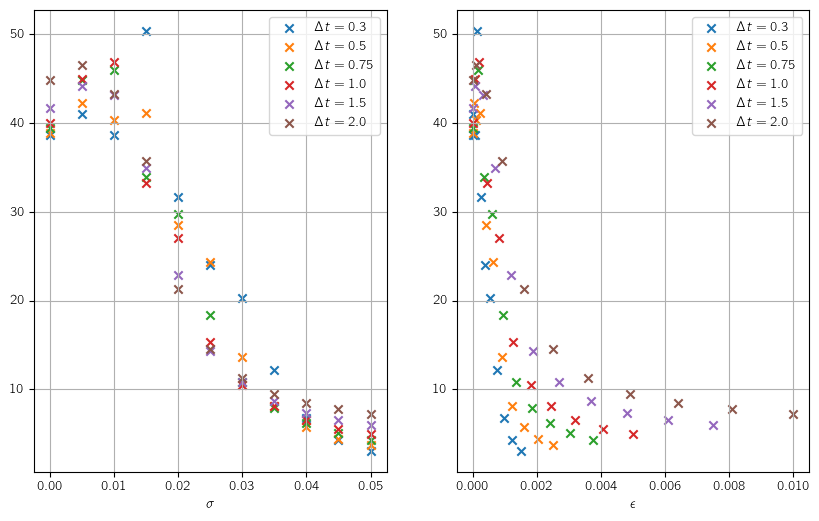

In [40]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
for subsample_step_TO in dt_dict.keys():
    t_escape_dict = dt_dict[subsample_step_TO]
    dt_eff_TO = dt_traj * subsample_step_TO
    axes[0].scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
                    np.array([t_escape_dict[k].mean()
                              for k in sorted(t_escape_dict.keys())]),
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_xlabel(r'$\sigma$')
    axes[1].scatter(np.array(sorted(t_escape_dict.keys())),  # * (0.05/np.max(np.array(sorted(t_escape_dict.keys())))),
                    np.array([t_escape_dict[k].mean()
                              for k in sorted(t_escape_dict.keys())]),
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[1].set_xlabel(r'$\epsilon$')
    axes[1].legend()
    axes[1].grid(True)

In [30]:
np.sqrt(0.05) * (0.05/np.sqrt(0.05))

np.float64(0.05)

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_435962/2970939718.py:8: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
/tmp/ipykernel_435962/2970939718.py:13: SyntaxWarning: invalid escape sequence '\D'
  label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")


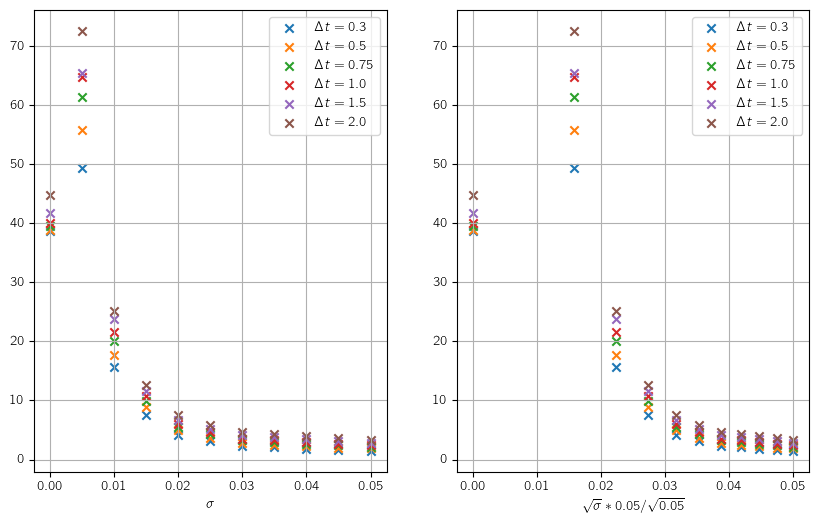

In [39]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
for subsample_step_TO in dt_dict_MonteCarlo.keys():
    escape_results = dt_dict_MonteCarlo[subsample_step_TO]
    means = np.array([np.mean(v)
                      for k, v in sorted(escape_results[blocking_idx].items())])
    dt_eff_TO = dt_traj * subsample_step_TO
    axes[0].scatter(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float), means,
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_xlabel(r'$\sigma$')
    axes[1].scatter(np.sqrt(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float)) * (0.05/np.sqrt(0.05)), means,
                    label=f'$\Delta t={dt_eff_TO:.2}$', marker="x")
    axes[1].legend()
    axes[1].grid(True)
    axes[1].set_xlabel(r'$\sqrt{\sigma}*0.05/\sqrt{0.05}$')

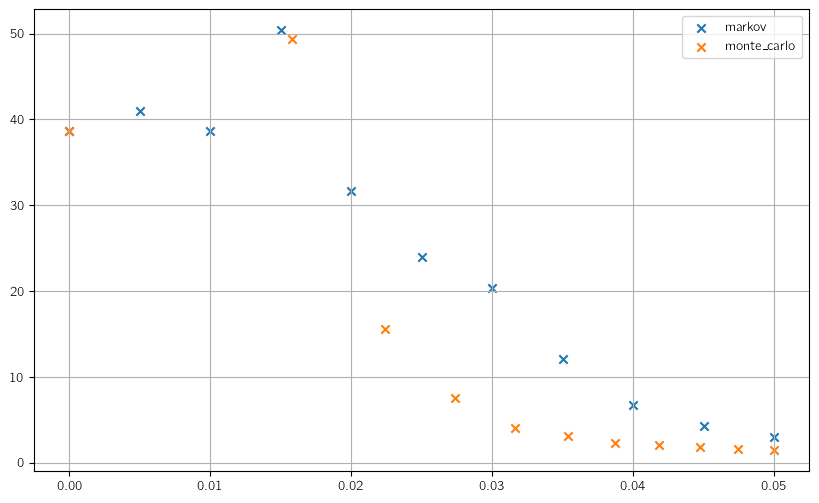

In [37]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
t_escape_dict = dt_dict[30]
dt_eff_TO = dt_traj * 30
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
           np.array([t_escape_dict[k].mean()
                     for k in sorted(t_escape_dict.keys())]),
           label=f'markov', marker="x")
escape_results = dt_dict_MonteCarlo[30]
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(np.sqrt(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float)) * (0.05/np.sqrt(0.05)), means,
           label=f'monte_carlo', marker="x")
ax.legend()
ax.grid(True)

## dt as low as possible

In [88]:
max_points = 7e4
subsample_step_TO = 20
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_TO = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
labels_TO = classify_new_trajectory(
    det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
)
print(np.asarray(calculate_escape_times(
    labels_TO, dt=dt_eff_TO)[blocking_idx]).mean())
entries = np.where(
    (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])

L = make_L3d(det_traj_TO, 0)
Q = L[labels_TO[:-1] == blocking_idx][:,
                                      labels_TO[:-1] == blocking_idx].tocsr()
t_escape = solve_escape_from_Q(Q) * dt_eff_TO
print(t_escape[indices_in_reduced].mean())
print("entries:", entries.shape[0])
print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)
print(f"dt: {dt_eff_TO}")

35.75535714285714
[sparse-direct] used splu (n=20022, nnz=19910, density=4.967e-05).
35.753571428571426
entries: 112
blocking states: (20023,)
dt: 0.2


In [89]:

t_escape_dict = {}
for sig in np.linspace(0, 0.05, 101):
    eps = (2 * dt_eff_TO * sig**2)
    print(f"Processing epsilon = {eps:.6f}")

    L = make_L3d(det_traj_TO, eps)
    Q = L[labels_TO[:-1] == blocking_idx][:,
                                          labels_TO[:-1] == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q)

    # Store
    t_escape_dict[eps] = t_escape[indices_in_reduced] * dt_eff_TO

dt_dict[subsample_step_TO] = t_escape_dict
escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin")):
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, int(2e6))[::subsample_step_TO, :]

    # classify
    labels_new = classify_new_trajectory(
        det_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=dt_eff_TO)

    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)
    dt_dict_MonteCarlo[subsample_step_TO] = escape_results

Processing epsilon = 0.000000
[sparse-direct] used splu (n=20022, nnz=19910, density=4.967e-05).
Processing epsilon = 0.000000
[sparse-direct] used splu (n=20022, nnz=501403, density=0.001251).
Processing epsilon = 0.000000
[sparse-direct] used splu (n=20022, nnz=1211716, density=0.003023).
Processing epsilon = 0.000001
[sparse-direct] used splu (n=20022, nnz=2037159, density=0.005082).
Processing epsilon = 0.000002
[sparse-direct] used splu (n=20022, nnz=2948792, density=0.007356).
Processing epsilon = 0.000003
[sparse-direct] used splu (n=20022, nnz=3916051, density=0.009769).
Processing epsilon = 0.000004
[sparse-direct] used splu (n=20022, nnz=4970321, density=0.0124).
Processing epsilon = 0.000005
[sparse-direct] used splu (n=20022, nnz=6070719, density=0.01514).
Processing epsilon = 0.000006
[sparse-direct] used splu (n=20022, nnz=7221313, density=0.01801).
Processing epsilon = 0.000008
[sparse-direct] used splu (n=20022, nnz=8373632, density=0.02089).
Processing epsilon = 0.0000

In [92]:
with open('markov_dt.pkl', 'wb') as f:
    pickle.dump(dt_dict, f)

with open('monte_carlo_dt.pkl', 'wb') as f:
    pickle.dump(dt_dict_MonteCarlo, f)

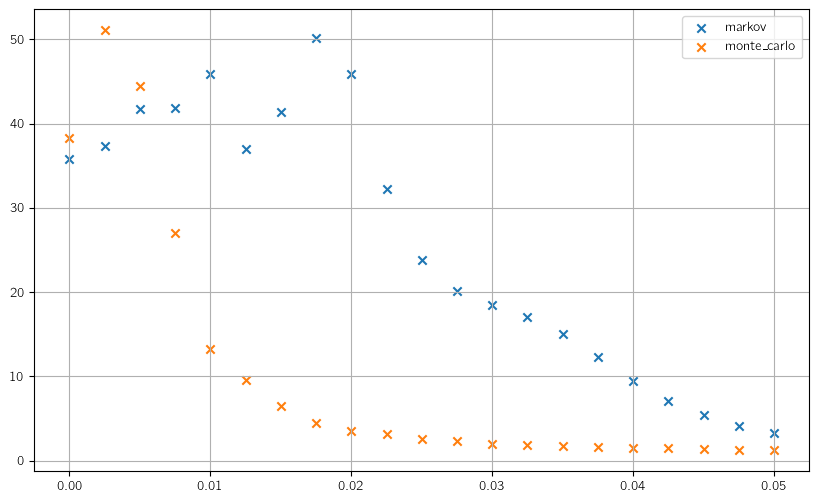

In [25]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
dt_eff_TO = dt_traj * subsample_step_TO
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
           np.array([t_escape_dict[k].mean()
                     for k in sorted(t_escape_dict.keys())]),
           label=f'markov', marker="x")
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float), means,
           label=f'monte_carlo', marker="x")
ax.legend()
ax.grid(True)

## Check epsloglog for regime

In [18]:
det_traj_TO.shape

(70000, 6)

In [36]:
max_points = 2e6
subsample_step_TO = 1
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_TO = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
labels_TO = classify_new_trajectory(
    det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
)
# print(np.asarray(calculate_escape_times(
#     labels_TO, dt=dt_eff_TO)[blocking_idx]).mean())
entries = np.where(
    (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])

# L = make_L3d(det_traj_TO, 0)
# Q = L[labels_TO[:-1] == blocking_idx][:,
#                                       labels_TO[:-1] == blocking_idx].tocsr()
# t_escape = solve_escape_from_Q(Q) * dt_eff_TO
# print(t_escape[indices_in_reduced].mean())
print("entries:", entries.shape[0])
print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)
print(f"dt: {dt_eff_TO}")

entries: 161
blocking states: (571370,)
dt: 0.01


In [ ]:
eps_max = 2*dt_eff_TO*0.05**2
points = find_nearby_indices(
    det_traj_TO, labels_TO, eps=eps_max, regime=blocking_idx)

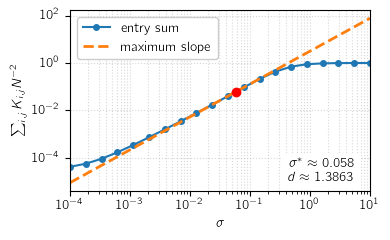

In [45]:
sigmas_loglog = np.logspace(-4, 1, 20)
eps_vals = 2*sigmas_loglog**2*dt_eff_TO
sums = np.array([affinity_entry_sum(det_traj_TO[points], eps, chunk=1000)
                for eps in eps_vals]) / det_traj_TO[points].shape[0]**2
plot_loglog_slope_analysis(sigmas_loglog, sums)

## check entry distribution

In [49]:
entries_100 = entries + 3000
entries_100 = entries_100[entries_100 < labels_TO.shape[0]]

In [66]:
(1+2+3+4+5+6+7+8+9)**2

2025

Text(0, 0.5, 'X6')

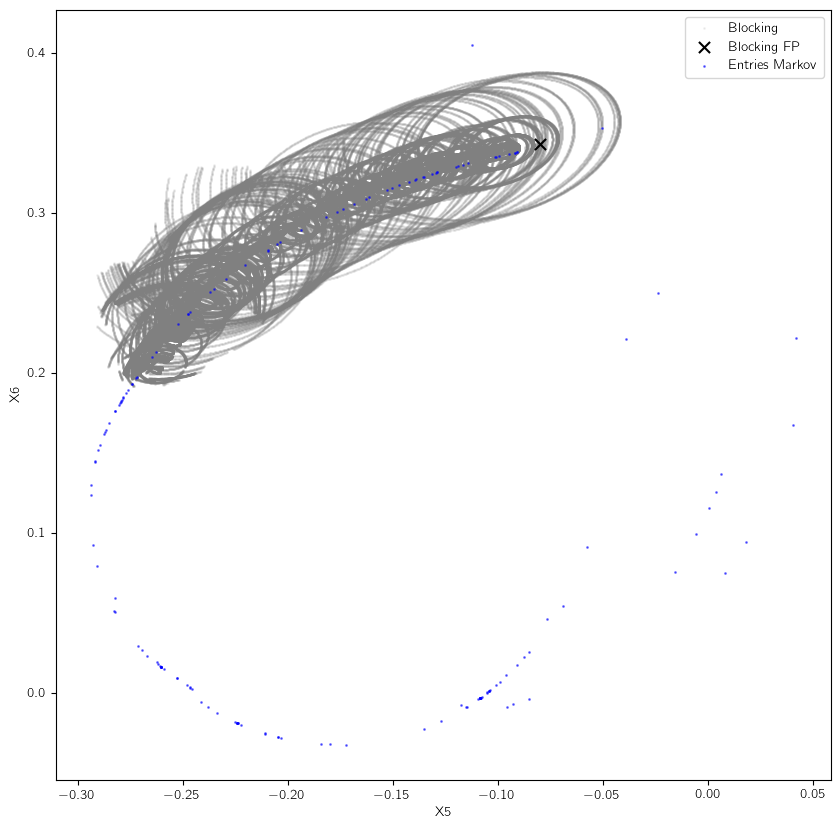

In [50]:

blocking_points = det_traj_TO[np.where(labels_TO == blocking_idx)[0]]
plt.figure(figsize=(10, 10))
sc = plt.scatter(blocking_points[:, 4], blocking_points[:, 5], color="gray", s=1, label='Blocking',
                 rasterized=True, alpha=0.1)
plt.scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
            alpha=1, marker="x", label="Blocking FP")
# plt.scatter(fixed[1, 4], fixed[1, 5], c='red', s=64,
#             alpha=1, marker="x", label="Zonal FP")

plt.scatter(det_traj_TO[entries_100, 4], det_traj_TO[entries_100, 5], c='blue', s=1, label='Entries Markov',
            rasterized=True, alpha=0.5)

plt.legend()
plt.xlabel("X5")
plt.ylabel("X6")

In [49]:
max_points = 7e4
subsample_step_TO = 20
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_TO = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
labels_TO = classify_new_trajectory(
    det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
)
entries = np.where(
    (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
blocking_points = det_traj_TO[np.where(labels_TO == blocking_idx)[0]]

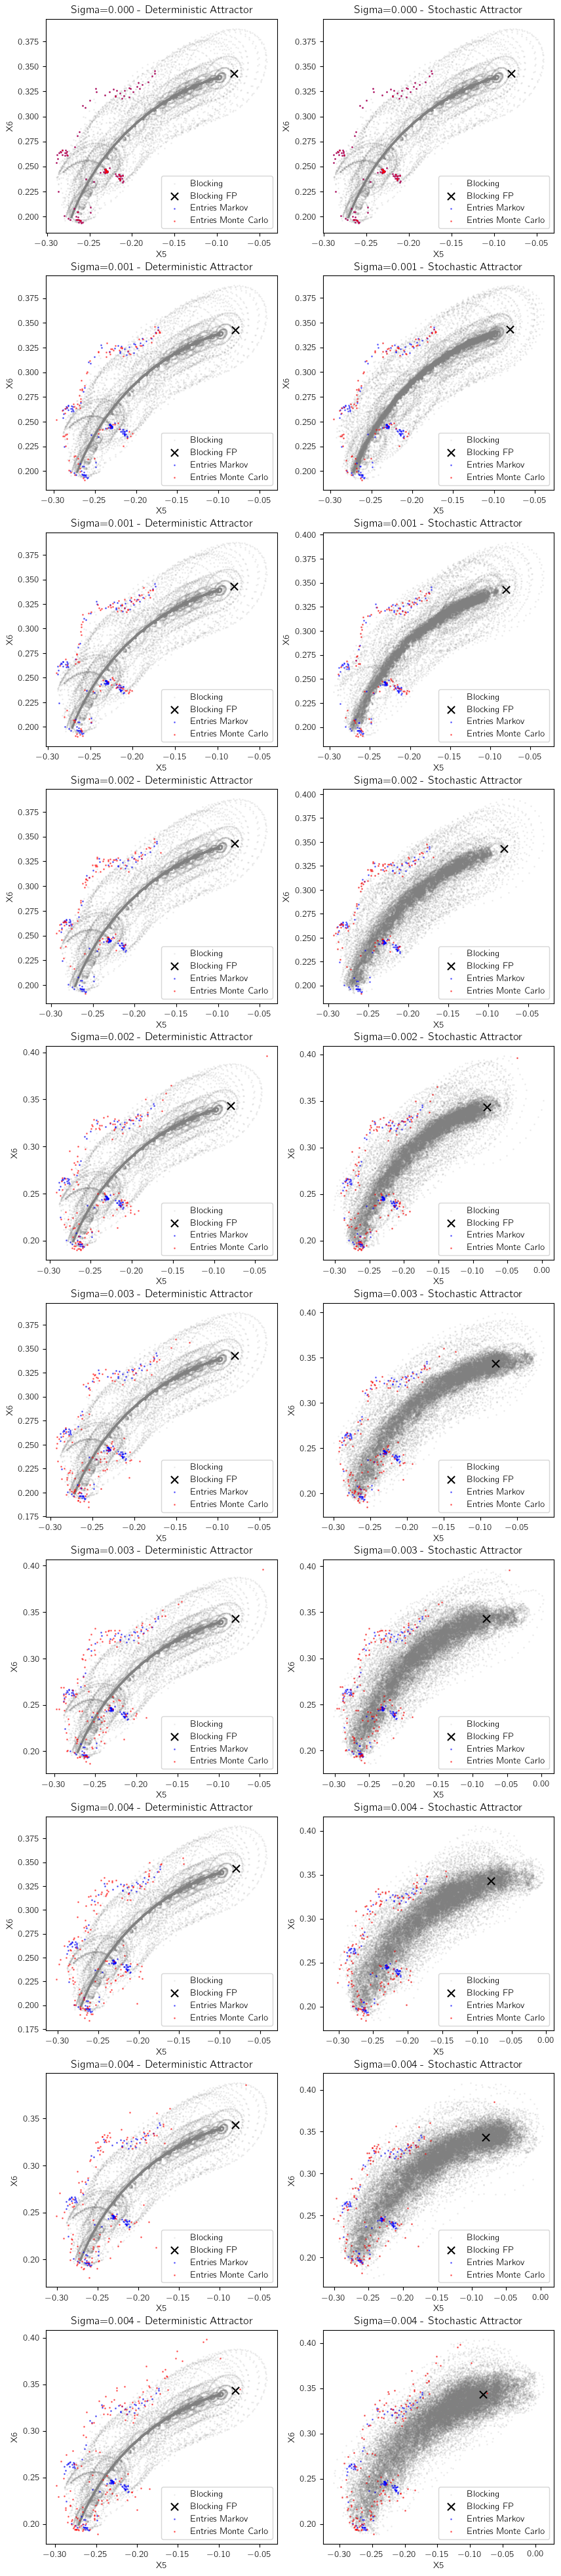

In [50]:
n_sigs = 10
fig, axes = plt.subplots(nrows=n_sigs, ncols=2, figsize=(10, 5*n_sigs))
files = sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))
# step = len(files) / (n_sigs * 2)
step = 1
for i in range(n_sigs):
    fname = files[int(round(i * step))]
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    # get Monte Carlo entries
    sig_data = load_d(fname, 6, int(2e6))[:t_fin:subsample_step_TO, :]

    # classify
    labels_new = classify_new_trajectory(
        det_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )
    blocking_points_sig = sig_data[np.where(labels_new == blocking_idx)[0]]
    entries_MC = np.where(
        (labels_new[:-1] != blocking_idx) & (labels_new[1:] == blocking_idx))[0]+1

    # plot with deterministic attractor
    axes[i, 0].scatter(blocking_points[:, 4], blocking_points[:, 5], color="gray", s=1, label='Blocking',
                       rasterized=True, alpha=0.1)
    axes[i, 0].scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
                       alpha=1, marker="x", label="Blocking FP")
    axes[i, 0].scatter(det_traj_TO[entries, 4], det_traj_TO[entries, 5], c='blue', s=1, label='Entries Markov',
                       rasterized=True, alpha=0.5)
    axes[i, 0].scatter(sig_data[entries_MC, 4], sig_data[entries_MC, 5], c='red', s=1, label='Entries Monte Carlo',
                       rasterized=True, alpha=0.5)
    axes[i, 0].legend()
    axes[i, 0].set_xlabel("X5")
    axes[i, 0].set_ylabel("X6")
    axes[i, 0].set_title(f'Sigma={sigma_val:.3f} - Deterministic Attractor')
    # plot with stochastic attractor
    axes[i, 1].scatter(blocking_points_sig[:, 4], blocking_points_sig[:, 5], color="gray", s=1, label='Blocking',
                       rasterized=True, alpha=0.1)
    axes[i, 1].scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
                       alpha=1, marker="x", label="Blocking FP")
    axes[i, 1].scatter(det_traj_TO[entries, 4], det_traj_TO[entries, 5], c='blue', s=1, label='Entries Markov',
                       rasterized=True, alpha=0.5)
    axes[i, 1].scatter(sig_data[entries_MC, 4], sig_data[entries_MC, 5], c='red', s=1, label='Entries Monte Carlo',
                       rasterized=True, alpha=0.5)
    axes[i, 1].legend()
    axes[i, 1].set_xlabel("X5")
    axes[i, 1].set_ylabel("X6")
    axes[i, 1].set_title(f'Sigma={sigma_val:.3f} - Stochastic Attractor')

## See if escape time is the same for nearest entry points
- for every single deterministic entry point 
    - find the closest entry point in the stochastic trajectory
    - calculate the escape time using markov chain and monte carlo
- compare mean over all entry points for each sigma 


In [90]:
max_points = 7e4
subsample_step_TO = 20
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_TO = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
labels_TO = classify_new_trajectory(
    det_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
)
entries = np.where(
    (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])
print("entries:", entries.shape[0])
print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)
print(f"dt: {dt_eff_TO}")
blocking_points = det_traj_TO[np.where(labels_TO == blocking_idx)[0]]

entries: 112
blocking states: (20023,)
dt: 0.2


In [91]:
n_sigs = 100
files = sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))
step = len(files) / (n_sigs)
results = {}
for i in range(n_sigs):
    fname = files[int(round(i * step))]
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    sig_data = load_d(fname, 6, int(2e6))[::subsample_step_TO, :]
    labels_new = classify_new_trajectory(
        det_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )
    entries_MC = np.where(
        (labels_new[:-1] != blocking_idx) & (labels_new[1:] == blocking_idx))[0]+1
    tree = cKDTree(sig_data[entries_MC])
    # get markov escape times
    eps = (2 * dt_eff_TO * sigma_val**2)

    L = make_L3d(det_traj_TO, eps)
    Q = L[labels_TO[:-1] == blocking_idx][:,
                                          labels_TO[:-1] == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q)

    markov_dict = {}
    monte_dict = {}
    sig_entries = {}

    for i, entry_point in enumerate(det_traj_TO[entries]):
        det_entry_idx = entries[i]
        markov_dict[det_entry_idx] = t_escape[indices_in_reduced][i] * dt_eff_TO

        # find closest entry point in monte carlo

        dist, idx = tree.query(entry_point)
        mc_entry_global_idx = entries_MC[int(idx)]
        following = labels_new[mc_entry_global_idx + 1:]  # slice after entry
        leave_offsets = np.where(following != blocking_idx)[0]
        if leave_offsets.size == 0:
            # never left within available data — record NaN (or a large sentinel if you prefer)
            monte_escape_time = np.nan
        else:
            # first time index where it left:
            leave_idx = mc_entry_global_idx + 1 + int(leave_offsets[0])
            steps = leave_idx - mc_entry_global_idx
            monte_dict[det_entry_idx] = steps * dt_eff_TO
        sig_entries[det_entry_idx] = sig_data[mc_entry_global_idx]
    results[sigma_val] = {
        "markov": markov_dict,
        "monte_carlo": monte_dict,
        "sig_entries": sig_entries
    }

[sparse-direct] used splu (n=20022, nnz=19910, density=4.967e-05).
[sparse-direct] used splu (n=20022, nnz=501403, density=0.001251).
[sparse-direct] used splu (n=20022, nnz=1211716, density=0.003023).
[sparse-direct] used splu (n=20022, nnz=2037159, density=0.005082).
[sparse-direct] used splu (n=20022, nnz=2948792, density=0.007356).
[sparse-direct] used splu (n=20022, nnz=3916051, density=0.009769).
[sparse-direct] used splu (n=20022, nnz=4970321, density=0.0124).
[sparse-direct] used splu (n=20022, nnz=6070719, density=0.01514).
[sparse-direct] used splu (n=20022, nnz=7221313, density=0.01801).
[sparse-direct] used splu (n=20022, nnz=8373632, density=0.02089).
[sparse-direct] used splu (n=20022, nnz=9563247, density=0.02386).
[sparse-direct] used splu (n=20022, nnz=10823361, density=0.027).
[sparse-direct] used splu (n=20022, nnz=12143177, density=0.03029).
[sparse-direct] used splu (n=20022, nnz=13524506, density=0.03374).
[sparse-direct] used splu (n=20022, nnz=14934124, density=

In [93]:
with open("entry_results.pkl", "wb") as f:
    pickle.dump(results, f)

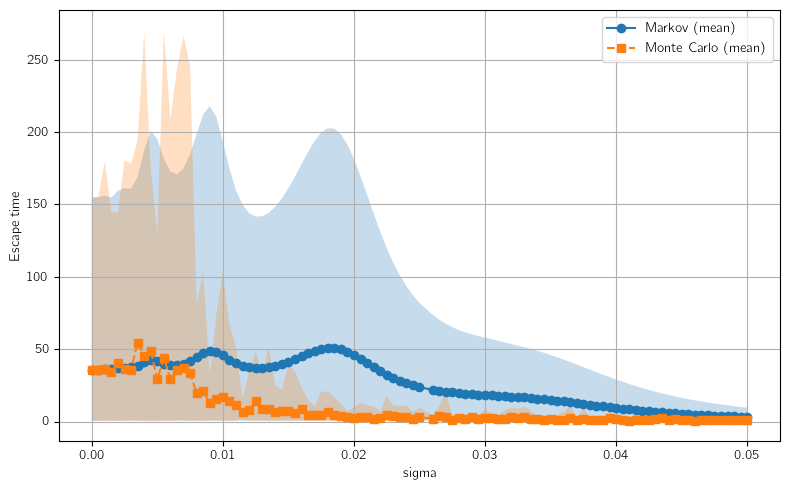

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# ------- helper to get mean and IQR from a dict of values -------


def mean_iqr_from_dict(d):
    """Return mean, q25, q75 (all as numpy scalars/arrays). d may be {} or contain NaNs."""
    if not d:
        return np.nan, np.nan, np.nan
    arr = np.asarray(list(d.values()), dtype=float)
    # if arr is empty, return nans
    if arr.size == 0:
        return np.nan, np.nan, np.nan
    mean = np.nanmean(arr)
    # use nanpercentile to ignore NaNs when computing percentiles
    q5, q95 = np.nanpercentile(arr, [5, 95])
    return mean, q5, q95


# ------- build sorted arrays from results dict -------
sigmas_sorted = sorted(results.keys())           # keys are sigma floats
sigmas = np.asarray(sigmas_sorted, dtype=float)

m_mean = []
m_q5 = []
m_q95 = []
c_mean = []
c_q5 = []
c_q95 = []

for s in sigmas_sorted:
    entry = results[s]
    mm, mq5, mq95 = mean_iqr_from_dict(entry.get("markov", {}))
    cm, cq5, cq95 = mean_iqr_from_dict(entry.get("monte_carlo", {}))
    m_mean.append(mm)
    m_q5.append(mq5)
    m_q95.append(mq95)
    c_mean.append(cm)
    c_q5.append(cq5)
    c_q95.append(cq95)

m_mean = np.asarray(m_mean, dtype=float)
m_q5 = np.asarray(m_q5, dtype=float)
m_q95 = np.asarray(m_q95, dtype=float)

c_mean = np.asarray(c_mean, dtype=float)
c_q5 = np.asarray(c_q5, dtype=float)
c_q95 = np.asarray(c_q95, dtype=float)

# ------- plotting -------
plt.figure(figsize=(8, 5))

# Markov trace + IQR band
plt.plot(sigmas, m_mean, marker='o', linestyle='-', label='Markov (mean)')
# fill_between handles nan by not shading there
plt.fill_between(sigmas, m_q5, m_q95, alpha=0.25, linewidth=0)

# Monte Carlo trace + IQR band
plt.plot(sigmas, c_mean, marker='s',
         linestyle='--', label='Monte Carlo (mean)')
plt.fill_between(sigmas, c_q5, c_q95, alpha=0.25, linewidth=0)

plt.xlabel('sigma')
plt.ylabel('Escape time')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
entry["monte_carlo"]

{}

# Try with stochastic trajectory again...

/tmp/ipykernel_11138/902239569.py:32: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_11138/902239569.py:34: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


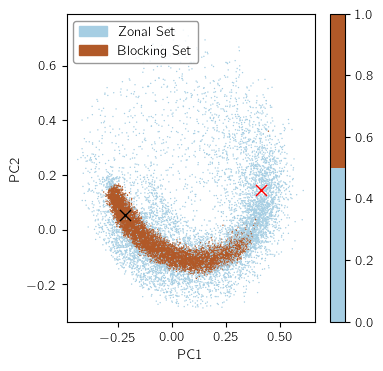

In [56]:
# sig_clust = 0.005
# subsample_step = 10
# epsilon = sig_clust**2 * 2 * subsample_step
# n_eig = 12
# n_clusters = 2
# n_init = 10
# eig_indices = [1, 2, 3, 4]   # zero-based eigenvector indices to use
# random_state = 0
# stoch_traj = load_d(
#     "./cdv_model/data/dataOro20_sigma0p00500000.bin", 6, 200000)[::subsample_step, :]

# # DMM, A = diffusion_maps_matrix(det_traj, epsilon)

# L = make_L3d(stoch_traj, epsilon)

# # --- compute clusters from TO ---
# stoch_cluster_res = compute_clusters_from_TO(L.T,
#                                              n_eig=n_eig,
#                                              n_clusters=n_clusters,
#                                              n_init=n_init,
#                                              eig_indices=eig_indices,
#                                              random_state=random_state)
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(stoch_traj)
fixed_pcs = pca.transform(fixed)
labels = stoch_cluster_res["labels"].copy()
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(labels)))
sc = plt.scatter(PC_scores[:-1, 0], PC_scores[:-1, 1],
                 c=labels, s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

handles = [
    mpatches.Patch(color=cmap(0), label=f'Zonal Set'),
    mpatches.Patch(color=cmap(1), label=f'Blocking Set')
]
plt.legend(
    handles=handles,
    loc='upper left',           # position inside the plot
    frameon=True,
    framealpha=0.8,             # slightly transparent background
    facecolor='white',
    edgecolor='gray'
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(sc)
# cbar = plt.colorbar(sc, ticks=range(len(np.unique(det_cluster_res["labels"]))))
cbar.set_label('cluster')
# cbar.set_ticklabels(range(len(np.unique(det_cluster_res["labels"]))))

In [ ]:
epsilon

0.0005

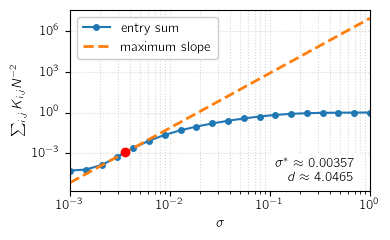

In [9]:
sigmas_loglog = np.logspace(-3, 0, 20)
eps_vals = 2*sigmas_loglog**2*subsample_step
sums = np.array([affinity_entry_sum(stoch_traj, eps, chunk=1000)
                for eps in eps_vals]) / stoch_traj.shape[0]**2
plot_loglog_slope_analysis(sigmas_loglog, sums)

In [57]:
# check above
blocking_idx = 1  # <- change this
blocking_mask = labels == blocking_idx
dt_traj = 1e-2

In [58]:
subsample_step_TO = 20
max_points = 1e4
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_TO = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00050000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
labels_TO = classify_new_trajectory(
    stoch_traj[:-1], labels, det_traj_TO, k=20, threshold=0.5
)
print(np.asarray(calculate_escape_times(
    labels_TO, dt=dt_eff_TO)[blocking_idx]).mean())
entries = np.where(
    (labels_TO[:-1] != blocking_idx) & (labels_TO[1:] == blocking_idx))[0]+1
indices_in_reduced = np.nonzero(labels_TO == blocking_idx)[0].searchsorted(
    entries[np.isin(entries, np.nonzero(labels_TO == blocking_idx)[0])])

L = make_L3d(det_traj_TO, 0)
Q = L[labels_TO[:-1] == blocking_idx][:,
                                      labels_TO[:-1] == blocking_idx].tocsr()
t_escape = solve_escape_from_Q(Q) * dt_eff_TO
print(t_escape[indices_in_reduced].mean())
print("entries:", entries.shape[0])
print("blocking states:", np.where(labels_TO == blocking_idx)[0].shape)

21.08085106382979
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=4907, density=0.0001999).
21.080851063829794
entries: 47
blocking states: (4954,)


In [59]:

t_escape_dict = {}
for sig in np.linspace(0, 0.05, 501)[::25]:
    eps = (2 * dt_eff_TO * sig**2)
    print(f"Processing epsilon = {eps:.6f}")

    L = make_L3d(det_traj_TO, eps)
    Q = L[labels_TO[:-1] == blocking_idx][:,
                                          labels_TO[:-1] == blocking_idx].tocsr()
    t_escape = solve_escape_from_Q(Q)

    # Store
    t_escape_dict[eps] = t_escape[indices_in_reduced] * dt_eff_TO
    print(t_escape_dict[eps].mean())

Processing epsilon = 0.000000
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=4907, density=0.0001999).
21.080851063829794
Processing epsilon = 0.000003
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=163134, density=0.006647).
20.76861088784958
Processing epsilon = 0.000010
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=539157, density=0.02197).
21.453679152666304
Processing epsilon = 0.000023
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=914564, density=0.03727).
21.151106002479512
Processing epsilon = 0.000040
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=1312389, density=0.05347).
22.31543999002409
Processing epsilon = 0.000063
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=1712862, density=0.06979).
20.120518031746478
Processing epsilon = 0.000090
[iterative] GMRES converged with ILU preconditioner (n=4954, nnz=2133831, density=0.08695).
18.367954131036612
Processing epsilon

In [64]:

escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))[:25:]:
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, int(2e6))[::subsample_step_TO, :]

    # classify
    labels_new = classify_new_trajectory(
        stoch_traj[:-1], labels, sig_data, k=20, threshold=0.5
    )

    esc_dict = calculate_escape_times(labels_new, dt=dt_eff_TO)
    print(np.asarray(esc_dict[blocking_idx]).mean())
    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

Processing sigma=0.0
18.167037861915368
Processing sigma=0.0005
21.84830699774266
Processing sigma=0.001
21.978741865509765
Processing sigma=0.0015
21.83370288248337
Processing sigma=0.002
22.676989247311827
Processing sigma=0.0025
25.726244343891402
Processing sigma=0.003
27.19357798165138
Processing sigma=0.0035
28.39030023094688
Processing sigma=0.004
29.464203233256352
Processing sigma=0.0045
28.88937093275488
Processing sigma=0.005
27.738655462184873
Processing sigma=0.0055
28.059836065573773
Processing sigma=0.006
27.092737430167595
Processing sigma=0.0065
17.53905013192612
Processing sigma=0.007
16.805320435308346
Processing sigma=0.0075
14.534888653234358
Processing sigma=0.008
12.519742883379248
Processing sigma=0.0085
11.341145833333336
Processing sigma=0.009
10.229497568881687
Processing sigma=0.0095
9.823312883435584
Processing sigma=0.01
8.123545331529094
Processing sigma=0.0105
7.487515762925599
Processing sigma=0.011
6.82894438138479
Processing sigma=0.0115
6.06372067648

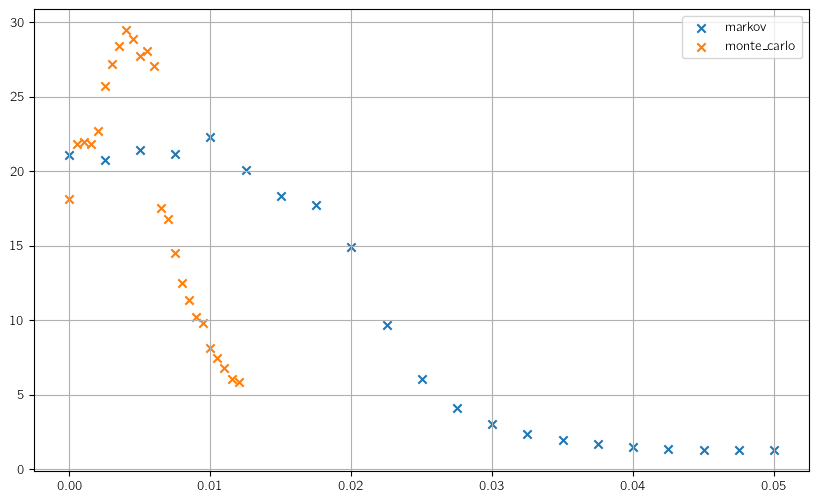

In [65]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
           np.array([t_escape_dict[k].mean()
                     for k in sorted(t_escape_dict.keys())]),
           label=f'markov', marker="x")
means = np.array([np.mean(v)
                  for k, v in sorted(escape_results[blocking_idx].items())])
ax.scatter(np.asarray(sorted(escape_results[blocking_idx].keys()), dtype=float), means,
           label=f'monte_carlo', marker="x")
ax.legend()
ax.grid(True)

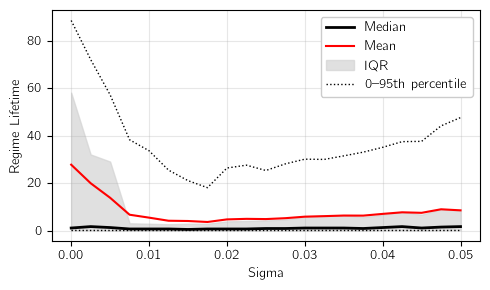

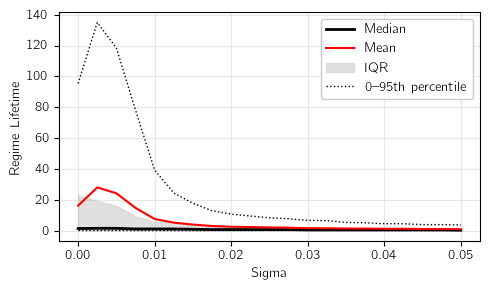

In [64]:
for regime in [0, 1]:
    plot_lifetime_distributions_lines(
        escape_results, regime=regime, logx=False)

# Coming back to HMM

In [8]:
inits = np.r_[fixed, [(fixed[0] + fixed[1]) / 2]]
dt_traj = 1e-2
max_points = 7e4
subsample_step_TO = 20
t_fin = int(subsample_step_TO * max_points)
dt_eff_TO = dt_traj * subsample_step_TO
det_traj_HMM = load_d(
    "./cdv_model/datafine/dataOro20_sigma0p00000000.bin", 6, int(2e6))[:t_fin:subsample_step_TO, :]
state_centers, states_sd, states = fit_hmm(
    det_traj_HMM, 3, initial_centers=inits)

Transition Matrix:
Shape: (3, 3)
State 1: [0.9867 0.0095 0.0039]
State 2: [0.0134 0.9866 0.0000]
State 3: [0.0002 0.0046 0.9952]



/tmp/ipykernel_11138/3726046105.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
/tmp/ipykernel_11138/3726046105.py:11: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,


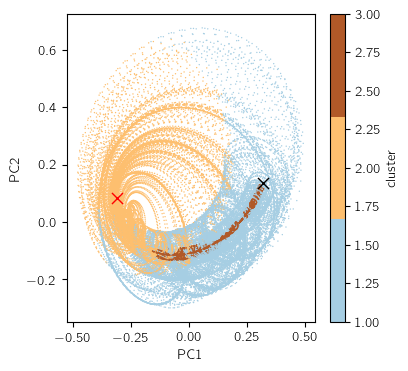

In [11]:
pca = PCA(n_components=3)
PC_scores = pca.fit_transform(det_traj_HMM)
fixed_pcs = pca.transform(fixed)
plt.figure(figsize=(4, 4))
cmap = plt.get_cmap("Paired", len(np.unique(states)))
sc = plt.scatter(PC_scores[:, 0], PC_scores[:, 1],
                 c=states, s=1, linewidth=0, cmap=cmap, label='Clusters',
                 rasterized=True)
plt.scatter(fixed_pcs[0, 0], fixed_pcs[0, 1], c='black', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")
plt.scatter(fixed_pcs[1, 0], fixed_pcs[1, 1], c='red', s=64, alpha=1,
            edgecolors='black', linewidths=1, marker="x")

plt.xlabel("PC1")
plt.ylabel("PC2")

cbar = plt.colorbar(sc)
cbar.set_label('cluster')

In [15]:
blocking_idx = 3  # <- change this

blocking_mask = np.nonzero(states == blocking_idx)[0]
blocking_points = det_traj_HMM[blocking_mask]
states[~blocking_mask] = 0
entries = np.where(
    (states[:-1] != blocking_idx) & (states[1:] == blocking_idx))[0]+1
indices_in_reduced = blocking_mask.searchsorted(
    entries[np.isin(entries, blocking_mask)])
print("entries:", entries.shape[0])
print("blocking states:", blocking_mask.shape)

entries: 98
blocking states: (15680,)


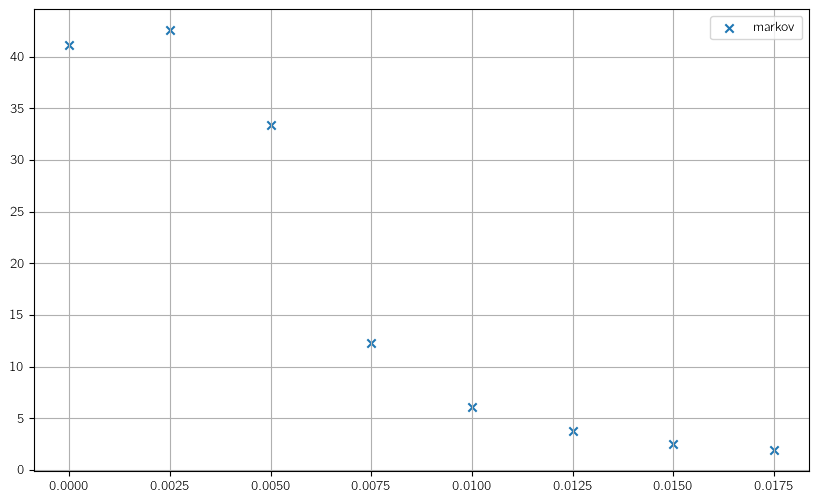

In [83]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.scatter(np.sqrt(np.array(sorted(t_escape_dict.keys())) / (dt_eff_TO*2)),
           np.array([t_escape_dict[k].mean()
                     for k in sorted(t_escape_dict.keys())]),
           label=f'markov', marker="x")

ax.legend()
ax.grid(True)

In [80]:

t_escape_dict = {}
for sig in np.linspace(0, 0.05, 501)[::25]:
    eps = (2 * dt_eff_TO * sig**2)
    print(f"Processing epsilon = {eps:.6f}")

    L = make_L3d(det_traj_HMM, eps)
    Q = L[blocking_mask[:-1]][:, blocking_mask[:-1]].tocsr()
    t_escape = solve_escape_from_Q(Q)

    # Store
    t_escape_dict[eps] = t_escape[indices_in_reduced] * dt_eff_TO
    print(t_escape_dict[eps].mean())

Processing epsilon = 0.000000
[sparse-direct] used splu (n=20151, nnz=20053, density=4.938e-05).
41.12448979591837
Processing epsilon = 0.000003
[sparse-direct] used splu (n=20151, nnz=4213244, density=0.01038).
42.55348540931513
Processing epsilon = 0.000010
[sparse-direct] used splu (n=20151, nnz=10491917, density=0.02584).
33.427329300408694
Processing epsilon = 0.000023
[sparse-direct] used splu (n=20151, nnz=18084008, density=0.04454).
12.268502248314174
Processing epsilon = 0.000040
[iterative] GMRES converged with ILU preconditioner (n=20151, nnz=26134156, density=0.06436).
6.109994557393499
Processing epsilon = 0.000063
[iterative] GMRES converged with ILU preconditioner (n=20151, nnz=34105789, density=0.08399).
3.7386750011243595
Processing epsilon = 0.000090
[iterative] GMRES converged with ILU preconditioner (n=20151, nnz=41946867, density=0.1033).
2.5559414289444895
Processing epsilon = 0.000123
[iterative] GMRES converged with ILU preconditioner (n=20151, nnz=49500592, den

KeyboardInterrupt: 

Labels new unique: [0 3]
Number in blocking: 24089
Labels new unique: [0 3]
Number in blocking: 19385
Labels new unique: [0 3]
Number in blocking: 1617
Labels new unique: [0 3]
Number in blocking: 218
Labels new unique: [0 3]
Number in blocking: 81


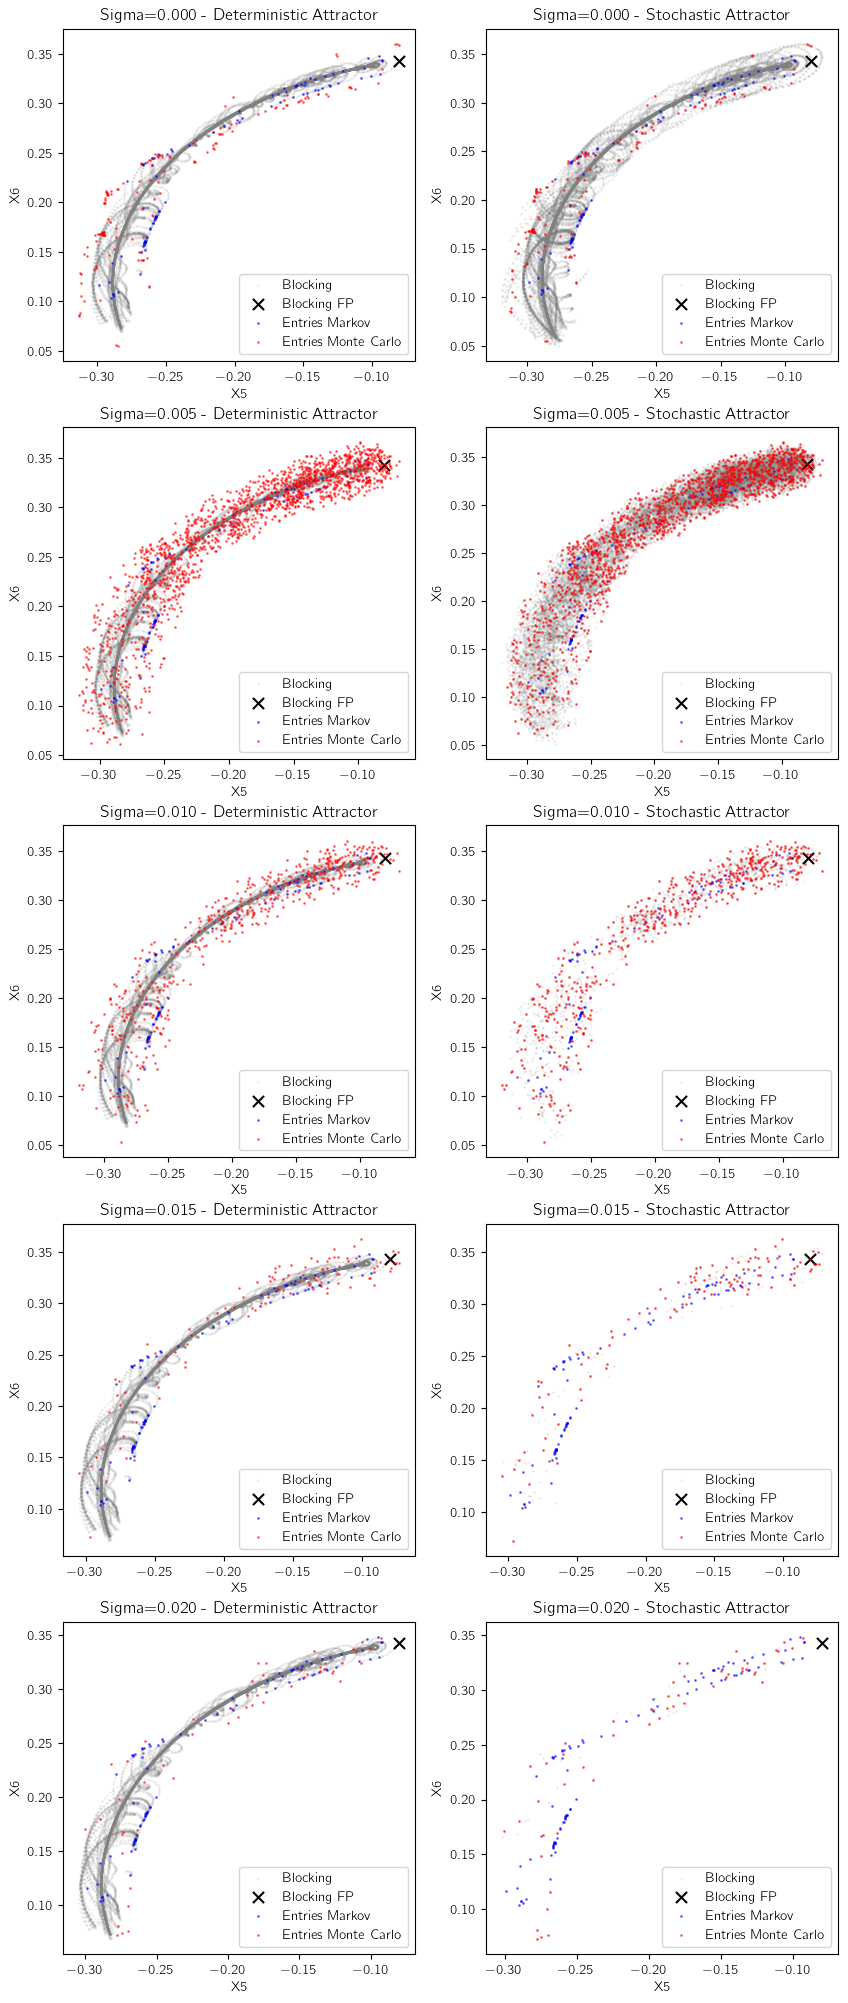

In [26]:
n_sigs = 5
fig, axes = plt.subplots(nrows=n_sigs, ncols=2, figsize=(10, 5*n_sigs))
files = sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))
step = len(files) / (n_sigs * 2)
for i in range(n_sigs):
    fname = files[int(round(i * step))]
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)

    # get Monte Carlo entries
    sig_data = load_d(fname, 6, int(2e6))[:t_fin:subsample_step_TO, :]

    # classify
    labels_new = classify_new_trajectory_radius(
        det_traj_HMM[:-1], states, sig_data, blocking_idx, 2e-2
    )
    print("Labels new unique:", np.unique(labels_new)
          )
    print("Number in blocking:", np.sum(labels_new == blocking_idx))
    blocking_points_sig = sig_data[np.where(labels_new == blocking_idx)[0]]
    entries_MC = np.where(
        (labels_new[:-1] != blocking_idx) & (labels_new[1:] == blocking_idx))[0]+1

    # plot with deterministic attractor
    axes[i, 0].scatter(blocking_points[:, 4], blocking_points[:, 5],
                       color="gray", s=1, label='Blocking',
                       rasterized=True, alpha=0.1)
    axes[i, 0].scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
                       alpha=1, marker="x", label="Blocking FP")
    axes[i, 0].scatter(blocking_points[indices_in_reduced, 4],
                       blocking_points[indices_in_reduced, 5], c='blue', s=1,
                       label='Entries Markov',
                       rasterized=True, alpha=0.5)
    axes[i, 0].scatter(sig_data[entries_MC, 4], sig_data[entries_MC, 5],
                       c='red', s=1, label='Entries Monte Carlo',
                       rasterized=True, alpha=0.5)
    axes[i, 0].legend()
    axes[i, 0].set_xlabel("X5")
    axes[i, 0].set_ylabel("X6")
    axes[i, 0].set_title(f'Sigma={sigma_val:.3f} - Deterministic Attractor')
    # plot with stochastic attractor
    axes[i, 1].scatter(blocking_points_sig[:, 4], blocking_points_sig[:, 5],
                       color="gray", s=1, label='Blocking',
                       rasterized=True, alpha=0.1)
    axes[i, 1].scatter(fixed[0, 4], fixed[0, 5], c='black', s=64,
                       alpha=1, marker="x", label="Blocking FP")
    axes[i, 1].scatter(blocking_points[indices_in_reduced, 4],
                       blocking_points[indices_in_reduced, 5], c='blue', s=1,
                       label='Entries Markov',
                       rasterized=True, alpha=0.5)
    axes[i, 1].scatter(sig_data[entries_MC, 4], sig_data[entries_MC, 5], c='red', s=1, label='Entries Monte Carlo',
                       rasterized=True, alpha=0.5)
    axes[i, 1].legend()
    axes[i, 1].set_xlabel("X5")
    axes[i, 1].set_ylabel("X6")
    axes[i, 1].set_title(f'Sigma={sigma_val:.3f} - Stochastic Attractor')

In [89]:

escape_results = {}  # plain dict
for fname in sorted(glob.glob("./cdv_model/datafine/dataOro20_sigma0p*.bin"))[::10]:
    # extract sigma string from filename (e.g. "0p050")
    match = re.search(r"sigma([0-9p]+)\.bin", fname)
    sigma_str = match.group(1).replace(
        "p", ".")   # e.g. "0p050" -> "0.050"
    sigma_val = float(sigma_str)
    print(f"Processing sigma={sigma_val}")

    sig_data = load_d(fname, 6, int(2e6))[:t_fin:subsample_step_TO, :]

    # classify
    labels_new = classify_new_trajectory_radius(
        det_traj_HMM[:-1], states, sig_data, blocking_idx, 1e-2
    )

    esc_dict = calculate_escape_times(labels_new, dt=dt_eff_TO)
    print(np.asarray(esc_dict[blocking_idx]).mean())
    # insert into dict safely
    for regime, times in esc_dict.items():
        if regime not in escape_results:
            escape_results[regime] = {}
        if sigma_val not in escape_results[regime]:
            escape_results[regime][sigma_val] = []
        escape_results[regime][sigma_val].extend(times)

Processing sigma=0.0
14000.0
Processing sigma=0.005
14000.0
Processing sigma=0.01
14000.0
Processing sigma=0.015
14000.0
Processing sigma=0.02
14000.0
Processing sigma=0.025
14000.0
Processing sigma=0.03
14000.0
Processing sigma=0.035


KeyError: 3